In [1]:
from google.colab import files
uploaded = files.upload()


Saving df_clean.csv to df_clean.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

df = pd.read_csv('df_clean.csv')

y = (df['IC50, mM'] > df['IC50, mM'].median()).astype(int)
X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(y.value_counts())


IC50, mM
0    501
1    500
Name: count, dtype: int64


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
prob = lr.predict_proba(X_test)[:,1]
print('LogisticRegression Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


LogisticRegression Accuracy: 0.517 F1: 0.682 ROC-AUC: 0.483


In [4]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:,1]
print('RandomForest Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


RandomForest Accuracy: 0.731 F1: 0.733 ROC-AUC: 0.79


In [5]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
prob = gb.predict_proba(X_test)[:,1]
print('GradientBoosting Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


GradientBoosting Accuracy: 0.711 F1: 0.716 ROC-AUC: 0.792


In [6]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
prob = xgb.predict_proba(X_test)[:,1]
print('XGBoost Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


XGBoost Accuracy: 0.716 F1: 0.716 ROC-AUC: 0.77


In [7]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
prob = dt.predict_proba(X_test)[:,1]
print('DecisionTree Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


DecisionTree Accuracy: 0.672 F1: 0.67 ROC-AUC: 0.69


RF и GB показали лучший ROC-AUC среди базовых моделей, поэтому тюним их.


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)
pred = grid_rf.predict(X_test)
prob = grid_rf.predict_proba(X_test)[:,1]
print('RF tuned Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
RF tuned Accuracy: 0.731 F1: 0.73 ROC-AUC: 0.79


In [9]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print(grid_gb.best_params_)
pred = grid_gb.predict(X_test)
prob = grid_gb.predict_proba(X_test)[:,1]
print('GB tuned Accuracy:', round(accuracy_score(y_test, pred), 3), 'F1:', round(f1_score(y_test, pred), 3), 'ROC-AUC:', round(roc_auc_score(y_test, prob), 3))


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
GB tuned Accuracy: 0.711 F1: 0.716 ROC-AUC: 0.792


GradientBoosting с learning_rate=0.1, ROC-AUC=0.792 показал себя лучше. RandomForest чуть хуже. Интересно что тюнинг почти не помог, видимо дефолтные параметры уже неплохие.

Pipeline с отбором 50 признаков через SelectKBest. Сравниваем результат с RF tuned на всех признаках. Если результат похожий значит большинство признаков были шумом.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

pipe = Pipeline([
    ('var', VarianceThreshold()),
    ('select', SelectKBest(f_classif, k=50)),
    ('clf', RandomForestClassifier(random_state=42))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
prob = pipe.predict_proba(X_test)[:, 1]
print('Pipeline ROC-AUC:', round(roc_auc_score(y_test, prob), 3))
print('Pipeline F1:     ', round(f1_score(y_test, pred), 3))

Pipeline ROC-AUC: 0.782
Pipeline F1:      0.724


Лучшая модель GradientBoosting с ROC-AUC=0.792. RandomForest чуть хуже. LogisticRegression дала ROC-AUC=0.483, то есть хуже случайного угадывания. Это значит что линейная граница разделения не работает для этих данных. Ансамблевые методы справляются намного лучше за счет улавливания нелинейных зависимостей.

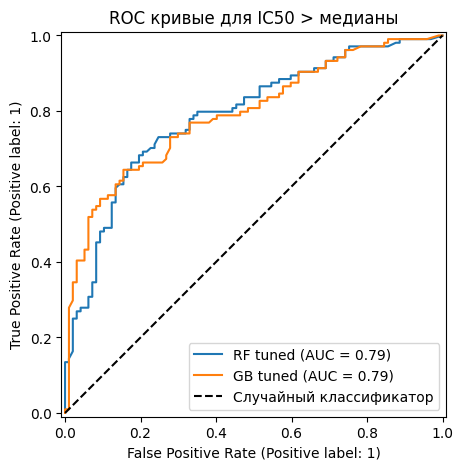

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(grid_rf, X_test, y_test, ax=ax, name='RF tuned')
RocCurveDisplay.from_estimator(grid_gb, X_test, y_test, ax=ax, name='GB tuned')
ax.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
ax.set_title('ROC кривые для IC50 > медианы')
ax.legend()
plt.show()